# BOOKING SUCCESS RATE ANALYSIS

## 1. Introduction

This project analyses booking data to identify factors affecting
the success rate of bookings.

The analysis focuses particularly on the behaviour of Tablet users
and identifies a significant decrease in success rate between
15:00 and 18:00.

The attached Python.csv contains information of 40000 bookings done on 25th of November.
The data fields are the following:

▪ **ID (Integer)**: Identifier of the reservation

▪ **PURCHASE_DATE (Date)**: Date when the booking was done

▪ **PURCHASE_HOUR (Integer)**: Hour when the booking was done

▪ **WEBSITE (String)**: Website where the booking was done. E.g. FR = French website

▪ **DEVICE (String)**: Device the customer used when purchasing the flight

▪ **DEPARTURE_DATE (Date)**: Date when the customer will take the flight

▪ **PROVIDER (String)**: Flight providers. If more than one, they are separated as follows: 
First outbound flight provider – Second outbound flight provider | Return flight provider
    
▪ **DISTANCE (Float)**: Distance in kilometers between origin and destination

▪ **STATUS (String)**: Status of the booking (when status = FINISHED,the booking is considered successful, otherwise it is not successful)

▪ **STEP (String)**: Point in the online back-end process where an error occurred resulting in the booking not being successfully confirmed

▪ **ERROR (String)**: Description of the error in the online back-end process that caused the booking not being successfully confirmed

▪ **SEAT (String)**: Indicates if the customer purchased a specific seat

▪ **BAGGAGE (String)**: Indicates if the customer purchased an extra baggage

## 2. Data Loading

In [ ]:
#We will first load the data:

import pandas as pd

df = pd.read_csv('C:/Users/eroch/Desktop/SQL_PROJECT_DATA/Edreams/python.csv')

In [37]:
# We check the data

print(df.head())

   ID   PURCHASE_DATE  PURCHASE_HOUR WEBSITE    DEVICE   DEPARTURE_DATE  \
0   0  25 of November             14      AU  Computer    1 of November   
1   1  25 of November             22      ES  Computer  12 of September   
2   2  25 of November             19      US  Computer       6 of April   
3   3  25 of November             23      ES  Computer    24 of October   
4   4  25 of November             23      GR  Computer   8 of September   

   PROVIDERS  DISTANCE    STATUS      STEP ERROR SEAT BAGGAGE Unnamed: 13  
0      j - w      1811        02  FINISHED   NaN  NaN    TRUE           F  
1  o - s | c     11270        92  FINISHED   NaN  NaN    TRUE        TRUE  
2  w - a | m      5985  FINISHED       NaN   NaN    T       F         NaN  
3  u - z | b     13951        86  FINISHED   NaN  NaN   FALSE        TRUE  
4  f - g | l     13665        20  FINISHED   NaN  NaN   False       FALSE  


In [38]:
# Also de data types

df.dtypes

ID                 int64
PURCHASE_DATE     object
PURCHASE_HOUR      int64
WEBSITE           object
DEVICE            object
DEPARTURE_DATE    object
PROVIDERS         object
DISTANCE           int64
STATUS            object
STEP              object
ERROR             object
SEAT              object
BAGGAGE           object
Unnamed: 13       object
dtype: object

## 3. Questions

We will check the questions and clean the data as we try to answer them.

---
- 1. Compute the **average Advance Purchase (AP)** which is the difference in days from the purchase date and the departure date. Hypothesis should be written explicitly.

     **AP = DEPARTURE _DATE – PURCHASE_DATE**

---

There are some issues when checking the data. 

First the PURCHASE_DATE and DEPARTURE_DATE have data type "object" so they need to be converted to date time.
Also we don't have a year, so if we consider both PURCHASE_DATE and DEPARTURE_DATE to have the same year
and calculate the difference between both we could get negative differences in case the purchase date was made a year before. 
If we only consider the days, we can see that there are purchase days that would take place after the departure date, 
which makes no sense.

For example:
    
    PURCHASE_DATE     PURCHASE_HOUR WEBSITE    DEVICE    DEPARTURE_DATE  
    25 of November             14      AU     Computer    1 of November

We are also finding errores because some dates appear out of range, 
which means that there are dates that are not real (such as 31st of February)

In [39]:
# We will convert first the PURCHASE_DATE and DEPARTURE_DATE to date and check the incorrect dates:

purchase_test = pd.to_datetime(
    df["PURCHASE_DATE"].str.replace(" of ", " "),
    format="%d %B",
    errors="coerce"
)

departure_test = pd.to_datetime(
    df["DEPARTURE_DATE"].str.replace(" of ", " "),
    format="%d %B",
    errors="coerce"
)

print("PURCHASE_DATE issues:")
print(df.loc[purchase_test.isna(), "PURCHASE_DATE"].value_counts())

print("\nDEPARTURE_DATE issues:")
print(df.loc[departure_test.isna(), "DEPARTURE_DATE"].value_counts())

PURCHASE_DATE issues:
Series([], Name: PURCHASE_DATE, dtype: int64)

DEPARTURE_DATE issues:
31 of February     126
30 of February     122
31 of November     118
31 of June         111
31 of September    107
31 of April        106
29 of February     104
Name: DEPARTURE_DATE, dtype: int64


The errors are in the Departure Date column only, not in the Purchase Date, we can find here are dates that don't exist.

So we are going to apply some changes.

If the day of purchase is later than the departure date, we are going to consider that it belongs to a previous year. 

To do this we are going to check the number of day of the year for each date and add 365 days if the purchase belongs to the previous year

We are also going to change the non existing departure dates, and since they are supposed to be the last dates of the month, we are going to get the correct last dates of the month. 

In [8]:
import pandas as pd
import calendar

# We create a function to convert "25 of November" (for example) to number of day of the year

def day_of_year(date_string):
    
    day, month = date_string.replace(" of ", " ").split()
    day = int(day)
    
    # We convert the date to number
    month_number = pd.to_datetime(month, format="%B").month
    
    # We get the last valid day of the month
    last_day = calendar.monthrange(2021, month_number)[1]
    
    # If the day does not exist, we use the correct last day of the month
    day = min(day, last_day)
    
    # We calculate the day of the year
    return pd.Timestamp(year=2021, month=month_number, day=day).dayofyear


# We create numeric versions of the dates

purchase_day = df["PURCHASE_DATE"].apply(day_of_year)
departure_day = df["DEPARTURE_DATE"].apply(day_of_year)


# We calculate AP = DEPARTURE _DATE – PURCHASE_DATE

df["AP"] = departure_day - purchase_day

# If the departure is before the purchase, we asume that it belongs to next year.
# We will be getting a negative number for AP, so we will add 365 days to the difference, 
# to increase 1 year to departure date

df.loc[df["AP"] < 0, "AP"] += 365

In [40]:
# We can see now that the AP is already calculated even when the purchase_date>departure_date

print(df.head())

   ID   PURCHASE_DATE  PURCHASE_HOUR WEBSITE    DEVICE   DEPARTURE_DATE  \
0   0  25 of November             14      AU  Computer    1 of November   
1   1  25 of November             22      ES  Computer  12 of September   
2   2  25 of November             19      US  Computer       6 of April   
3   3  25 of November             23      ES  Computer    24 of October   
4   4  25 of November             23      GR  Computer   8 of September   

   PROVIDERS  DISTANCE    STATUS      STEP ERROR SEAT BAGGAGE Unnamed: 13  
0      j - w      1811        02  FINISHED   NaN  NaN    TRUE           F  
1  o - s | c     11270        92  FINISHED   NaN  NaN    TRUE        TRUE  
2  w - a | m      5985  FINISHED       NaN   NaN    T       F         NaN  
3  u - z | b     13951        86  FINISHED   NaN  NaN   FALSE        TRUE  
4  f - g | l     13665        20  FINISHED   NaN  NaN   False       FALSE  


---
- 2. What is the success rate of each provider individually (a, b, c, d, ..., z)? The success rate is computed when the status is equal to FINISHED over all bookings.

     **SUCCESS RATE = (STATUS = FINISHED)/ALL**

---

Since PROVIDERS can contain differenet values such as "j - w", "o - s | c", etc., we need to split them to get the different providers. 

In [41]:
# We will first create a copy of the PROVIDERS column
providers = df["PROVIDERS"].copy()

# We will replace the characters - and | for a single character that splits the values
providers = providers.str.replace(" - ", "|")
providers = providers.str.replace(" ", "")

# We split providers
providers = providers.str.split("|")

# Each providers is going to be a different row
providers = providers.explode()

# We join it to the previous matching Status
provider_status = pd.DataFrame({
    "PROVIDER": providers,
    "STATUS": df.loc[providers.index, "STATUS"]
})

# We calculate the total number of bookings per provider
total = provider_status.groupby("PROVIDER").size()

# We calculate how many of them have STATUS = FINISHED
finished = (
    provider_status["STATUS"].eq("FINISHED")
    .groupby(provider_status["PROVIDER"])
    .sum()
)

# Success rate
success_rate = (finished / total * 100).sort_index()

print(success_rate)

PROVIDER
a    13.125000
b    13.459774
c    13.905418
d    12.636166
e    14.016672
f    14.692091
g    14.451411
h    13.654743
i    14.135959
j    15.415633
k    12.215644
l    13.859275
m    14.335224
n    13.262519
o    13.498623
p    11.946050
q    12.953692
r    12.167874
s    14.008148
t    13.531758
u    13.545568
v    12.874065
w    12.816553
x    13.928013
y    13.050415
z    13.584680
dtype: float64


In [42]:
# We could present the data in a more underdstandable and clean way:

success_rate_df = pd.DataFrame({
    "Total Bookings": total,
    "Finished": finished,
    "Success Rate (%)": success_rate
})

success_rate_df

# As we see the success rate goes between 12-15%

,Total Bookings,Finished,Success Rate (%)
PROVIDER,,,
a,3200,420,13.125000
b,3269,440,13.459774
c,3193,444,13.905418
d,3213,406,12.636166
e,3239,454,14.016672
f,3199,470,14.692091
g,3190,461,14.451411
h,3215,439,13.654743
i,3148,445,14.135959


---
- 3. Was there any trend change in the success rate of any device along the day? (Please visualize it in a plot) What was the root cause? (Please specify the step and the error). Did any of the variables (website, distance, seat, etc.) have any effect on this?
---

We need to do 3 different analysis:

1.- Check how the Success Rate for each DEVICE changes during the day. We need also a plot for this.

2.- Identify where and how the changes appear and look for a cause (STEP + ERROR).

3.- Check if variables as WEBSITE, DISTANCE, SEAT, BAGGAGE, etc. have any impact.

---

1.- Success rate according to PURCHASE_HOUR and DEVICE

---

In [43]:

success_by_device_hour = (
    df.groupby(["DEVICE", "PURCHASE_HOUR"])["STATUS"]
      .agg(
          total="count",
          finished=lambda x: (x == "FINISHED").sum()
      )
)

success_by_device_hour["success_rate"] = (
    success_by_device_hour["finished"]
    / success_by_device_hour["total"]
    * 100
)

success_by_device_hour = success_by_device_hour.reset_index()

success_by_device_hour

,DEVICE,PURCHASE_HOUR,total,finished,success_rate
0,Computer,0,882,135,15.306122
1,Computer,1,344,50,14.534884
2,Computer,2,202,26,12.871287
3,Computer,3,194,29,14.948454
4,Computer,4,180,26,14.444444
...,...,...,...,...,...
67,Tablet,19,561,76,13.547237
68,Tablet,20,532,75,14.097744
69,Tablet,21,563,71,12.611012
70,Tablet,22,741,104,14.035088


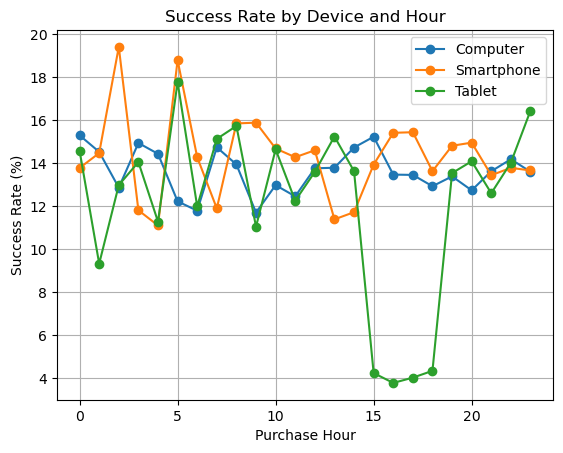

In [44]:
# We visualize the data with a Line Plot

import matplotlib.pyplot as plt

for device in success_by_device_hour["DEVICE"].unique():
    
    data = success_by_device_hour[
        success_by_device_hour["DEVICE"] == device
    ]
    
    plt.plot(
        data["PURCHASE_HOUR"],
        data["success_rate"],
        marker="o",
        label=device
    )

plt.xlabel("Purchase Hour")
plt.ylabel("Success Rate (%)")
plt.title("Success Rate by Device and Hour")
plt.legend()
plt.grid(True)
plt.show()

As we can see the success rate for "Tablet" decreases between 15:00 to 18:00. It falls from 14% to 4%

---

2. Identify where and how the changes appear and look for a cause (STEP + ERROR).

---

In [45]:
# We will check now the data for STEP & Error:

# We will filter first Device = Tablet and PURCHASE_HOUR between 15-18 
problem = df[ (df["DEVICE"] == "Tablet") & (df["PURCHASE_HOUR"].between(15, 18)) ].copy()

# We count the combinations of + ERROR 
error_impact = ( problem.groupby(["STEP", "ERROR"]) .size() .sort_values(ascending=False) .reset_index(name="count") )

# We show the most frequent errors

error_impact.head(10)

,STEP,ERROR,count
0,KO_ONLINE,F,1085
1,F,Technical error,232
2,KO_ONLINE,A,18
3,KO_ONLINE,E,16
4,KO_ONLINE,D,16
5,KO_ONLINE,B,14
6,KO_ONLINE,C,12
7,A,Connectivity issue with flight provider,2
8,C,Change of price by flight provider,2
9,C,Invalid data,1


In [46]:
# We can also check the error weight for each type

error_impact["percentage"] = ( error_impact["count"] / len(problem) * 100 ) 

error_impact.head(10)

,STEP,ERROR,count,percentage
0,KO_ONLINE,F,1085,57.866667
1,F,Technical error,232,12.373333
2,KO_ONLINE,A,18,0.960000
3,KO_ONLINE,E,16,0.853333
4,KO_ONLINE,D,16,0.853333
5,KO_ONLINE,B,14,0.746667
6,KO_ONLINE,C,12,0.640000
7,A,Connectivity issue with flight provider,2,0.106667
8,C,Change of price by flight provider,2,0.106667
9,C,Invalid data,1,0.053333


**Roughly 58% of all reservations for Tablet between 15:00 y las 18:00 have STEP = KO_ONLINE y ERROR = F.**

The main pattern for this error is:

STEP = KO_ONLINE
ERROR = F

*There are 1.085 cases for this combination and hour range.*

There are also 232 cases with:
STEP = F
SEAT = Technical error

It seems that there is an inconsistency in the data structure for some rows for the CSV. "Technical error" appears in the SEAT column too. 

---
3.- Check if variables as WEBSITE, DISTANCE, SEAT, BAGGAGE, etc. have any impact.

For this part we will be focusing on the hour interval (15:00–18:00) for the device Tablet and will will compare it with the rest of the data of other devices at the same hour.
This way we will be able to compare if WEBSITE, DISTANCE, SEAT o BAGGAGE can explain this decrease.

---

In [47]:
#We will again prepare first the problematic subset, which we will define as: Tablet between 15:00 and 18:00 

problem = df[ (df["DEVICE"] == "Tablet") & (df["PURCHASE_HOUR"].between(15, 18)) ].copy() 

# We will get the rest of the data for Devices which are not Tablet for the same range of Purchasing Hour.

tablet_normal = df[ ~( (df["DEVICE"] == "Tablet") & (df["PURCHASE_HOUR"].between(15, 18)) ) ].copy()

We will compare --**WEBSITE**--

For each website we will calculate:

Nbr of bookings
Nbr of FINISHED
success rate

In [48]:
website_comparison = (
    problem.groupby("WEBSITE")["STATUS"]
    .agg(
        total="count",
        finished=lambda x: (x == "FINISHED").sum()
    )
)

website_comparison["success_rate"] = (
    website_comparison["finished"]
    / website_comparison["total"]
    * 100
)

website_comparison = website_comparison.sort_values(
    "success_rate",
    ascending=False
)

website_comparison

#WEBSITE: there are differences between websites, but this doesn't seems to explain the decrease. 
#Success rates range from 1.6% and 8.1%.

,total,finished,success_rate
WEBSITE,,,
FR,111,9,8.108108
AR,124,9,7.258065
AU,111,7,6.306306
ES,121,6,4.958678
IT,124,6,4.838710
US,113,5,4.424779
GR,118,5,4.237288
NL,123,5,4.065041
JP,105,4,3.809524


We could check if a Website has a lower success rate during the range of time where the success rate decreased.

We can compare it to a normal behaviour of the data:

In [49]:
# This is the success rate out of the out of the time range with issues:
website_normal = (
    tablet_normal.groupby("WEBSITE")["STATUS"]
    .apply(lambda x: (x == "FINISHED").mean() * 100)
    .rename("normal_success_rate")
)

# We add the comparison
website_comparison = website_comparison.join(website_normal)

website_comparison["difference"] = (
    website_comparison["success_rate"]
    - website_comparison["normal_success_rate"]
)

website_comparison

# "difference" shows how the success rate change during the range of time with issues for each website.
# There are rate differences between 5.69 and 13.22

,total,finished,success_rate,normal_success_rate,difference
WEBSITE,,,,,
FR,111,9,8.108108,13.803419,-5.695311
AR,124,9,7.258065,14.555603,-7.297539
AU,111,7,6.306306,13.764163,-7.457857
ES,121,6,4.958678,14.340753,-9.382076
IT,124,6,4.838710,13.047103,-8.208393
US,113,5,4.424779,13.730356,-9.305577
GR,118,5,4.237288,13.114754,-8.877466
NL,123,5,4.065041,14.468261,-10.403220
JP,105,4,3.809524,13.308302,-9.498778


We compare -- **DISTANCE**--

We won't be able to group for each DISTANCE value, since this contains continous data, so we will have a lot of different values.

In [51]:
# We will create intervals for DISTANCE
bins = [0, 5000, 10000, 15000, 20000, float("inf")]
labels = [
    "0-5000",
    "5001-10000",
    "10001-15000",
    "15001-20000",
    "20000+"
]

problem["DISTANCE_GROUP"] = pd.cut(
    problem["DISTANCE"],
    bins=bins,
    labels=labels
)

tablet_normal["DISTANCE_GROUP"] = pd.cut(
    tablet_normal["DISTANCE"],
    bins=bins,
    labels=labels
)

# We use here the problematic hour subset
distance_comparison = (
    problem.groupby("DISTANCE_GROUP", observed=True)["STATUS"]
    .apply(lambda x: (x == "FINISHED").mean() * 100)
    .rename("problem_success_rate")
)

# Normal time period
distance_normal = (
    tablet_normal.groupby("DISTANCE_GROUP", observed=True)["STATUS"]
    .apply(lambda x: (x == "FINISHED").mean() * 100)
    .rename("normal_success_rate")
)

# We concat them
distance_comparison = pd.concat(
    [distance_comparison, distance_normal],
    axis=1
)

# Check the difference
distance_comparison["difference"] = (
    distance_comparison["problem_success_rate"]
    - distance_comparison["normal_success_rate"]
)

distance_comparison

,problem_success_rate,normal_success_rate,difference
DISTANCE_GROUP,,,
0-5000,5.000000,14.093462,-9.093462
5001-10000,4.646018,13.305828,-8.659810
10001-15000,3.870968,14.165704,-10.294736
15001-20000,2.928870,13.907075,-10.978205


**DISTANCE**: there seems to be some difference between the time with issues for longer DISTANCE values.
Longer flights have a lower success rate in the problematic time range and the difference with the normal rate increases with Distance.
However the impact is small to explain the combination of Tablet + 15–18h.

Compare --**SEAT**--

We will use the same procedure as with WEBSITE.

But first we need to check the data, because there are values that seem to belong to other columns:

In [52]:
seat_comparison = (
    problem.groupby("SEAT")["STATUS"]
    .agg(
        total="count",
        finished=lambda x: (x == "FINISHED").sum()
    )
)

seat_comparison["success_rate"] = (
    seat_comparison["finished"]
    / seat_comparison["total"]
    * 100
)

seat_comparison = seat_comparison.sort_values(
    "success_rate",
    ascending=False
)

seat_comparison

,total,finished,success_rate
SEAT,,,
0,32,11,34.375000
False,48,14,29.166667
T,61,16,26.229508
FALSE,41,10,24.390244
F,41,8,19.512195
True,37,6,16.216216
TRUE,40,6,15.000000
1,41,6,14.634146
Change of price by flight provider,5,0,0.000000


In [53]:
# We can see that there are values as "Technical error" that don't seem to belong to this column:

df["SEAT"].value_counts(dropna=False)

NaN                                        24754
Technical error                             1612
True                                        1051
F                                           1006
0                                            999
FALSE                                        995
TRUE                                         990
T                                            988
False                                        983
1                                            946
Invalid credit card details                  574
Change of price by flight provider           536
Risky booking                                525
Change of price by hotel provider            519
Invalid data                                 519
Charge declined by customer bank             518
Availability error from flight provider      510
Connectivity issue with hotel provider       506
Timeout between modules                      506
Availability error from hotel provider       494
Connectivity issue w

In [54]:
# We will clean the SEAT column, normalizing the data

df["SEAT_CLEAN"] = ( df["SEAT"] .astype(str) .str.strip() .str.upper() .map({ "TRUE": True, "T": True, "1": True, "FALSE": False, "F": False, "0": False }) )

In [55]:
# Now we will make the comparison for Device Tablet and the problematic time range:

# We create the df with issues
problem = df[
    (df["DEVICE"] == "Tablet") &
    (df["PURCHASE_HOUR"].between(15, 18))
].copy()


# And compare to the clean Seat column
seat_comparison = (
    problem.groupby("SEAT_CLEAN")["STATUS"]
    .agg(
        total="count",
        finished=lambda x: (x == "FINISHED").sum()
    )
)

seat_comparison["success_rate"] = (
    seat_comparison["finished"]
    / seat_comparison["total"]
    * 100
)

seat_comparison = seat_comparison.sort_values(
    "success_rate",
    ascending=False
)

seat_comparison


,total,finished,success_rate
SEAT_CLEAN,,,
False,162,43,26.543210
True,179,34,18.994413


The success rate for customers that Selected a Seat is 18,99% (true)
The ones that didnt select it got a 26,54% (false)

In [56]:
#It's important to note that there are many SEAT values that could not be converted, and don't really belong to this column.

seat_invalid = (
    problem.loc[
        problem["SEAT_CLEAN"].isna(),
        "SEAT"
    ]
    .value_counts()
)

seat_invalid


Technical error                            1082
Availability error from flight provider      12
Charge declined by customer bank             10
Connectivity issue with hotel provider       10
Invalid data                                  9
Timeout between modules                       7
Availability error from hotel provider        6
Invalid credit card details                   6
Change of price by flight provider            5
Change of price by hotel provider             5
Connectivity issue with flight provider       5
Risky booking                                 4
Name: SEAT, dtype: int64

Compare --BAGGAGE--

We first check its values, because there is something wrong here too:

In [57]:
df["BAGGAGE"].value_counts(dropna=False)

FALSE    5066
TRUE     5024
T        5021
False    5015
F        4979
True     4967
0        4967
1        4961
Name: BAGGAGE, dtype: int64

As we see the values should be only True/False, but we are getting this same information in different formats so we should group them

In [58]:
# We will create a normalized version of BAGGAGE 

df["BAGGAGE_CLEAN"] = ( df["BAGGAGE"] .astype(str) .str.strip() .str.upper() .map({ "TRUE": True, "T": True, "1": True, "FALSE": False, "F": False, "0": False }) )

df["BAGGAGE_CLEAN"].value_counts(dropna=False)

False    20027
True     19973
Name: BAGGAGE_CLEAN, dtype: int64

In [59]:
# We will create the problematic subset of the baggage for the purchase hour 15-18 

problem = df[ (df["DEVICE"] == "Tablet") & (df["PURCHASE_HOUR"].between(15, 18)) ].copy()

# We check the success rate

baggage_comparison = ( problem.groupby("BAGGAGE_CLEAN")["STATUS"] .agg( total="count", finished=lambda x: (x == "FINISHED").sum() ) )

baggage_comparison["success_rate"] = ( baggage_comparison["finished"] / baggage_comparison["total"] * 100 )

baggage_comparison

,total,finished,success_rate
BAGGAGE_CLEAN,,,
False,848,46,5.424528
True,1027,31,3.018500


For the Tablet **DEVICE between 15:00 and 18:00**
With BAGGAGE = False, the success rate is 5,42%.
With BAGGAGE = True, it drops to 3,02%.
This doesn't seem to be the root cause either for the drop between 15:00 and 18:00.
The difference could be focused on a general issue related to Tablet for the time 15:00 to 18:00

We can also recheck comparing the time range with issues and the rest of the hours for BAGGAGE_CLEAN

In [60]:
#I had to repeat some steps since I was getting errors.

# Clean Baggage again
df["BAGGAGE_CLEAN"] = (
    df["BAGGAGE"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({
        "TRUE": True,
        "T": True,
        "1": True,
        "FALSE": False,
        "F": False,
        "0": False
    })
)


# We define the problematic period again
problem = df[
    (df["DEVICE"] == "Tablet") &
    (df["PURCHASE_HOUR"].between(15, 18))
].copy()


# Create the rest of the cases for Tablet
tablet_normal = df[
    ~(
        (df["DEVICE"] == "Tablet") &
        (df["PURCHASE_HOUR"].between(15, 18))
    )
].copy()


# Success rate for BAGGAGE during the issue period
baggage_comparison = (
    problem.groupby("BAGGAGE_CLEAN")["STATUS"]
    .apply(lambda x: (x == "FINISHED").mean() * 100)
    .rename("problem_success_rate")
)


# Success rate for BAGGAGE for the rest of the time
baggage_normal = (
    tablet_normal.groupby("BAGGAGE_CLEAN")["STATUS"]
    .apply(lambda x: (x == "FINISHED").mean() * 100)
    .rename("normal_success_rate")
)


# Join both results
baggage_comparison = pd.concat(
    [baggage_comparison, baggage_normal],
    axis=1
)


# Get the difference
baggage_comparison["difference"] = (
    baggage_comparison["problem_success_rate"]
    - baggage_comparison["normal_success_rate"]
)


# Results
baggage_comparison

,problem_success_rate,normal_success_rate,difference
BAGGAGE_CLEAN,,,
False,5.424528,13.525210,-8.100682
True,3.018500,14.208804,-11.190303


## 4. SUMMARY

We are going to summarize all the information above to make it more easy to underdstand how the variables impact on the success drop.

We will set and clean the data again

In [61]:
# Clean Baggage
df["BAGGAGE_CLEAN"] = (
    df["BAGGAGE"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({
        "TRUE": True,
        "T": True,
        "1": True,
        "FALSE": False,
        "F": False,
        "0": False
    })
)


# Clean SEAT
df["SEAT_CLEAN"] = (
    df["SEAT"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({
        "TRUE": True,
        "T": True,
        "1": True,
        "FALSE": False,
        "F": False,
        "0": False
    })
)


# Issue hour range and device
problem = df[
    (df["DEVICE"] == "Tablet") &
    (df["PURCHASE_HOUR"].between(15, 18))
].copy()


# The rest of Tablet reservationsResto de reservas de Tablet
tablet_normal = df[
    ~(
        (df["DEVICE"] == "Tablet") &
        (df["PURCHASE_HOUR"].between(15, 18))
    )
].copy()

# Create distance groups
bins = [0, 5000, 10000, 15000, 20000, float("inf")]
labels = [
    "0-5000",
    "5001-10000",
    "10001-15000",
    "15001-20000",
    "20000+"
]

problem["DISTANCE_GROUP"] = pd.cut(
    problem["DISTANCE"],
    bins=bins,
    labels=labels
)

tablet_normal["DISTANCE_GROUP"] = pd.cut(
    tablet_normal["DISTANCE"],
    bins=bins,
    labels=labels
)


# Function to get success rate
def success_rate(data, variable):
    return (
        data.groupby(variable, observed=True)["STATUS"]
        .apply(lambda x: (x == "FINISHED").mean() * 100)
    )


In [62]:
# WEBSITE
website_problem = success_rate(problem, "WEBSITE")
website_normal = success_rate(tablet_normal, "WEBSITE")

website_result = pd.concat(
    [website_problem, website_normal],
    axis=1,
    keys=["Problem", "Normal"]
)

website_result["Difference"] = (
    website_result["Problem"] - website_result["Normal"]
)


# SEAT
seat_problem = success_rate(problem.dropna(subset=["SEAT_CLEAN"]), "SEAT_CLEAN")
seat_normal = success_rate(tablet_normal.dropna(subset=["SEAT_CLEAN"]), "SEAT_CLEAN")

seat_result = pd.concat(
    [seat_problem, seat_normal],
    axis=1,
    keys=["Problem", "Normal"]
)

seat_result["Difference"] = (
    seat_result["Problem"] - seat_result["Normal"]
)


# BAGGAGE
baggage_problem = success_rate(
    problem.dropna(subset=["BAGGAGE_CLEAN"]),
    "BAGGAGE_CLEAN"
)

baggage_normal = success_rate(
    tablet_normal.dropna(subset=["BAGGAGE_CLEAN"]),
    "BAGGAGE_CLEAN"
)

baggage_result = pd.concat(
    [baggage_problem, baggage_normal],
    axis=1,
    keys=["Problem", "Normal"]
)

baggage_result["Difference"] = (
    baggage_result["Problem"] - baggage_result["Normal"]
)


# DISTANCE
distance_problem = success_rate(problem, "DISTANCE_GROUP")
distance_normal = success_rate(tablet_normal, "DISTANCE_GROUP")

distance_result = pd.concat(
    [distance_problem, distance_normal],
    axis=1,
    keys=["Problem", "Normal"]
)

distance_result["Difference"] = (
    distance_result["Problem"] - distance_result["Normal"]
)

In [63]:
# We show the grouped results 
print("=== WEBSITE ===")
display(website_result)

print("=== SEAT ===")
display(seat_result)

print("=== BAGGAGE ===")
display(baggage_result)

print("=== DISTANCE ===")
display(distance_result)

=== WEBSITE ===


,Problem,Normal,Difference
WEBSITE,,,
AR,7.258065,14.555603,-7.297539
AU,6.306306,13.764163,-7.457857
CA,3.361345,13.987730,-10.626386
CH,3.636364,13.490364,-9.854000
CO,1.694915,13.166667,-11.471751
DE,3.252033,13.721233,-10.469201
ES,4.958678,14.340753,-9.382076
FR,8.108108,13.803419,-5.695311
GR,4.237288,13.114754,-8.877466


=== SEAT ===


,Problem,Normal,Difference
SEAT_CLEAN,,,
False,26.543210,68.725465,-42.182255
True,18.994413,70.073762,-51.079348


=== BAGGAGE ===


,Problem,Normal,Difference
BAGGAGE_CLEAN,,,
False,5.424528,13.525210,-8.100682
True,3.018500,14.208804,-11.190303


=== DISTANCE ===


,Problem,Normal,Difference
DISTANCE_GROUP,,,
0-5000,5.000000,14.093462,-9.093462
5001-10000,4.646018,13.305828,-8.659810
10001-15000,3.870968,14.165704,-10.294736
15001-20000,2.928870,13.907075,-10.978205


## 5. CONCLUSIONS

The main issue appears related to:
    
**DEVICE = Tablet**

**PURCHASE_HOUR = 15–18--- Success rate drops from ~14% to ~4%**

**STEP = KO_ONLINE + ERROR = F	1.085 casos (~58% of the range with issues)**

The analysis shows that the *main issue is strongly associated with Tablet bookings between 15:00 and 18:00. 
During this period, the success rate drops from approximately 14% to around 4%.*

The *dominant failure pattern is the combination of STEP = KO_ONLINE and ERROR = F, representing approximately 58% of all Tablet bookings during the problematic period.*

*This suggests a technical issue affecting the online booking process.*

WEBSITE does not appear to be the root cause because all websites experience a similar decrease in success rate, ranging from approximately 6 to 13 percentage points. 

DISTANCE also shows a consistent reduction across all ranges, indicating that trip length is not a key explanatory factor.

BAGGAGE shows a moderate effect, with bookings including baggage experiencing a slightly larger decreasein success rate than bookings without baggage. This suggests that baggage selection may increase the complexity of the booking flow, but it does not appear to be the primary cause.

SEAT should be interpreted carefully because the dataset contains data quality issues, including technical error messages stored in the SEAT column. Therefore, conclusionsregarding seat selection are less reliable.

Overall, **the evidence indicates that the issue is primarily related to a technical problem affecting Tablet users during the online booking process between 15:00 and 18:00, rather than being caused by website, distance, seat, or baggage characteristics.**